In [ ]:
from matplotlib import ticker
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm, t, chi2, skew, kurtosis
from datetime import timedelta

In [106]:
# Define tickers
tickers = ['AAPL', 'MSFT', 'NVDA', 'AMD', 'INTC', '^IXIC', '^GSPC']

# Download data
print("Downloading 5 years of stock data...")
data = yf.download(tickers, period='5y', progress=False)

data = data['Close']
logreturn = np.log(data/data.shift(1)).dropna()

# #check data
# print(f"Data downloaded: {len(data)} trading days")
# print(data)
# print(logreturn)

#allocate the stocks and index
F1 = logreturn['^IXIC']
F2 = logreturn['^GSPC']
stocks = ['AAPL', 'MSFT', 'NVDA', 'AMD', 'INTC']

/var/folders/0h/6py4kmhn53q8_2z7bqz0v1_h0000gn/T/ipykernel_15090/2626950221.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='5y', progress=False)


Part 1 and 2

In [107]:
##Part 1 and 2##
#regression and collect residuals
results = {}
residuals = {}

for stock in stocks:
    #stock returns (dependent variable)
    X = logreturn[stock]
    
    #Independent variable
    factors = pd.DataFrame({
        'const': 1,
        'NASDAQ': F1,
        'SP500': F2
    })
    
    #Ensure data are in the same time periods
    common_dates = X.index.intersection(factors.index)
    X_clean = X.loc[common_dates]
    factors_clean = factors.loc[common_dates]
    
    #Estimate model
    model = sm.OLS(X_clean, factors_clean).fit()

    #Get p-value for significance test
    pvalue = model.pvalues['const']
    
    # Test if alpha is significantly different from zero at 5% level
    pvalue_significant = pvalue < 0.05
    
    # Get residuals
    residuals[stock] = model.resid

    results[stock] = {
        'alpha': model.params['const'],
        'beta1_NASDAQ': model.params['NASDAQ'],
        'beta2_SP500': model.params['SP500'],
        'r_squared': model.rsquared,
        'pvalue': pvalue,
        'pvalue_significant_5pct': pvalue_significant,
        't-stat': model.tvalues['const']
    }

# Convert to DataFrame for easy access
results_df = pd.DataFrame(results).T
results_df = results_df[['alpha', 'beta1_NASDAQ', 'beta2_SP500', 'r_squared','pvalue','pvalue_significant_5pct','t-stat']]


#print the results
print(f'Regression output:')
print(results_df)

Regression output:
         alpha beta1_NASDAQ beta2_SP500 r_squared    pvalue  \
AAPL  0.000053     0.884991    0.151366  0.626844   0.86498   
MSFT  0.000248     1.043699   -0.150039  0.672136  0.353712   
NVDA  0.001337     2.981567   -1.653805  0.656158  0.014159   
AMD  -0.000227     2.411303   -1.104795   0.55948  0.703596   
INTC -0.001144     0.430628    0.830048    0.2906  0.086081   

     pvalue_significant_5pct    t-stat  
AAPL                   False  0.170073  
MSFT                   False  0.927757  
NVDA                    True   2.45665  
AMD                    False -0.380558  
INTC                   False -1.717795  


Part 3

In [108]:
##PART 3##
#create matrix of residuals
residuals_matrix = pd.DataFrame(residuals)

# Original returns correlation
original_returns = logreturn[stocks]
original_correlation = original_returns.corr()

# Residuals correlation
residual_correlation = residuals_matrix.corr()

# Step 4: Risk decomposition analysis
risk_analysis = pd.DataFrame(index=stocks)


for stock in stocks:
    r_squared = results[stock]['r_squared']
    
    risk_analysis.loc[stock, 'Systematic_Risk_%'] = r_squared * 100
    risk_analysis.loc[stock, 'Idiosyncratic_Risk_%'] = (1 - r_squared) * 100
    risk_analysis.loc[stock, 'R_Squared'] = r_squared



#print the results
print("Residual Matrix:")
print(residuals_matrix)

print("Correlation Matrix of returns:")
print(original_correlation)
print("Correlation Matrix of residuals:")
print(residual_correlation)

#print result of risk comparison
print("Risk analysis:")
print(risk_analysis)

Residual Matrix:
                AAPL      MSFT      NVDA       AMD      INTC
Date                                                        
2020-09-09  0.012383  0.016548  0.017102 -0.002088 -0.012510
2020-09-10 -0.012749 -0.010325 -0.002905 -0.007276  0.011146
2020-09-11 -0.007981 -0.000383  0.005599 -0.018555  0.009828
2020-09-14  0.011181 -0.010958  0.020877 -0.010262 -0.014715
2020-09-15 -0.009917  0.004264 -0.019374 -0.009863  0.003518
...              ...       ...       ...       ...       ...
2025-08-29  0.009347  0.005056 -0.011277 -0.014907 -0.012087
2025-09-02 -0.002195  0.004199 -0.007990  0.010497  0.004689
2025-09-03  0.027535 -0.009672 -0.024264 -0.019913 -0.016182
2025-09-04 -0.004435 -0.003974 -0.010492 -0.016126  0.015158
2025-09-05  0.000349 -0.026237 -0.032979 -0.070558 -0.000968

[1254 rows x 5 columns]
Correlation Matrix of returns:
Ticker      AAPL      MSFT      NVDA       AMD      INTC
Ticker                                                  
AAPL    1.000000  0.

Exercise III

In [134]:
##Part 1
# Stock returns
stocks_returns = logreturn[['AAPL', 'MSFT', 'NVDA', 'AMD', 'INTC']]

# Portfolio weights (rename to avoid conflict)
weights = np.ones(5)/5

# Portfolio returns
portfolio_returns = stocks_returns @ weights
portfolio_losses = -portfolio_returns

window = 250
alphas = [0.95, 0.99]
rolling_results = {}

# Rolling window VaR calculation
for alpha in alphas:
    VaR_HS = np.full_like(portfolio_returns, np.nan, dtype=float)
    VaR_N = np.full_like(portfolio_returns, np.nan, dtype=float)
    VaR_T = np.full_like(portfolio_returns, np.nan, dtype=float)

    for i in range(window, len(portfolio_returns)):
        window_data = portfolio_returns[i-window:i] 
        window_losses = -window_data
        # Historical Simulation
        VaR_HS[i] = np.quantile(window_losses, alpha)

        # Normal
        mu, sigma = np.mean(window_losses), np.std(window_losses, ddof=1)
        VaR_N[i] = (mu + sigma * norm.ppf(alpha))

        # Student-t
        df, loc, scale = t.fit(window_losses)
        VaR_T[i] = (loc + scale * t.ppf(alpha, df))

    rolling_results[alpha] = {
        'VaR_HS': VaR_HS,
        'VaR_N': VaR_N,
        'VaR_T': VaR_T
    }

# Create DataFrame for presentation
df_VaR_roll = pd.DataFrame({
    'VaR_HS_95%': rolling_results[0.95]['VaR_HS'],
    'VaR_Normal_95%': rolling_results[0.95]['VaR_N'],
    'VaR_StudentT_95%': rolling_results[0.95]['VaR_T'],
    'VaR_HS_99%': rolling_results[0.99]['VaR_HS'],
    'VaR_Normal_99%': rolling_results[0.99]['VaR_N'],
    'VaR_StudentT_99%': rolling_results[0.99]['VaR_T']
}, index=portfolio_returns.index)

print("VaR from rolling window of 250 days")
print(df_VaR_roll) #execution will take a while


VaR from rolling window of 250 days
            VaR_HS_95%  VaR_Normal_95%  VaR_StudentT_95%  VaR_HS_99%  \
Date                                                                   
2020-09-09         NaN             NaN               NaN         NaN   
2020-09-10         NaN             NaN               NaN         NaN   
2020-09-11         NaN             NaN               NaN         NaN   
2020-09-14         NaN             NaN               NaN         NaN   
2020-09-15         NaN             NaN               NaN         NaN   
...                ...             ...               ...         ...   
2025-08-29    0.031439        0.033722          0.028284    0.057101   
2025-09-02    0.031439        0.033847          0.028462    0.057101   
2025-09-03    0.031439        0.033893          0.028470    0.057101   
2025-09-04    0.031067        0.032952          0.027815    0.054367   
2025-09-05    0.031067        0.032894          0.027707    0.054367   

            VaR_Normal_99% 

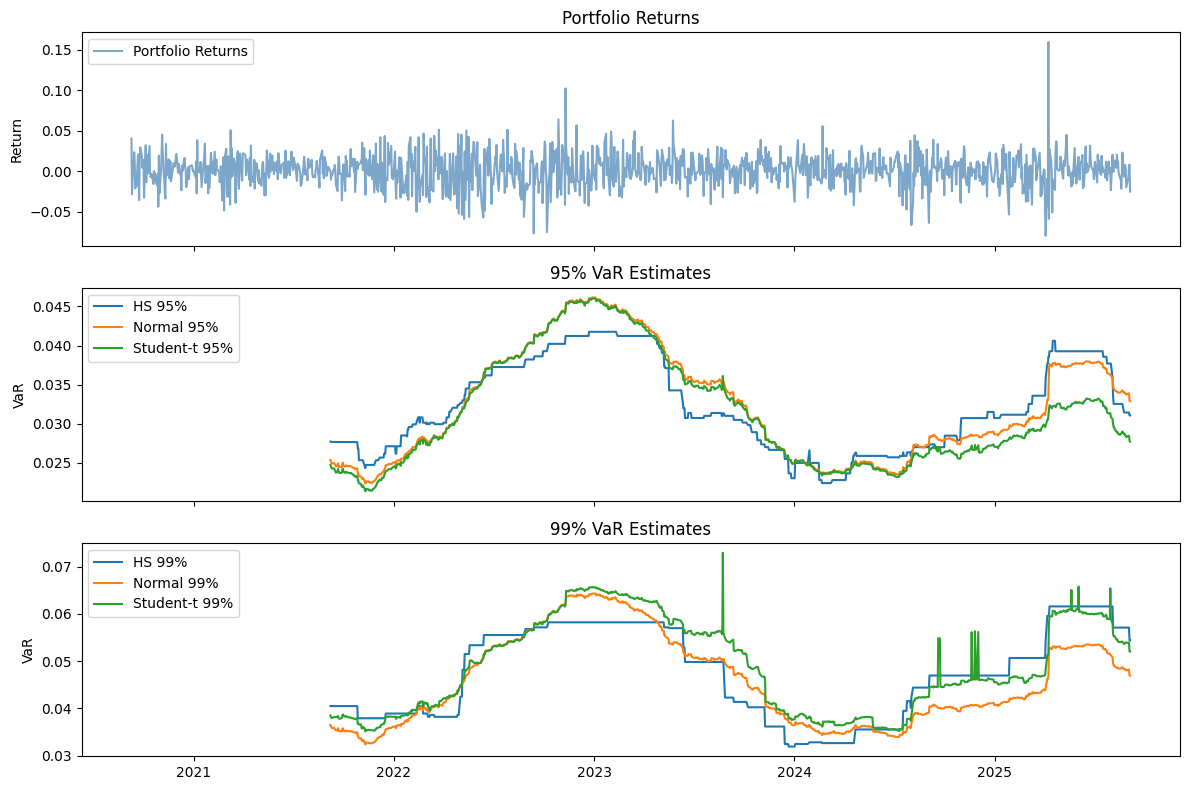

In [136]:
# Visualization
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Portfolio Returns
ax0.plot(portfolio_returns.index, portfolio_returns, label="Portfolio Returns", color="steelblue", alpha=0.7)
ax0.set_title("Portfolio Returns")
ax0.set_ylabel("Return")
ax0.legend()

# 95% Confidence Level
ax1.plot(df_VaR_roll.index, df_VaR_roll['VaR_HS_95%'], label="HS 95%")
ax1.plot(df_VaR_roll.index, df_VaR_roll['VaR_Normal_95%'], label="Normal 95%")
ax1.plot(df_VaR_roll.index, df_VaR_roll['VaR_StudentT_95%'], label="Student-t 95%")
ax1.legend()
ax1.set_title("95% VaR Estimates")
ax1.set_ylabel("VaR")

# 99% Confidence Level
ax2.plot(df_VaR_roll.index, df_VaR_roll['VaR_HS_99%'], label="HS 99%")
ax2.plot(df_VaR_roll.index, df_VaR_roll['VaR_Normal_99%'], label="Normal 99%")
ax2.plot(df_VaR_roll.index, df_VaR_roll['VaR_StudentT_99%'], label="Student-t 99%")
ax2.legend()
ax2.set_title("99% VaR Estimates")
ax2.set_ylabel("VaR")

plt.tight_layout()
plt.show()


Part 2

In [ ]:
# Data splitting
last_date = portfolio_returns.index[-1]
split_date = last_date - pd.DateOffset(years=3)

calibration_set = portfolio_returns.loc[:split_date]
backtest_set = portfolio_returns.loc[split_date + pd.Timedelta(days=1):]

methods = ["HS", "N", "T"]
backtest_results = {}

for alpha in alphas:
    actual_losses = -backtest_set
    results_alpha = {}

    for method in methods:
        VaR_series = pd.Series(rolling_results[alpha][f"VaR_{method}"], index=portfolio_returns.index)
        VaR_backtest = VaR_series.loc[backtest_set.index]

        # Violations as Series
        violations = (actual_losses > VaR_backtest).astype(int)
        results_alpha[f"violations_{method}"] = violations
        results_alpha[f"actual_count_{method}"] = violations.sum()

    total_days = len(backtest_set)
    expected_violations = (1 - alpha) * total_days
    results_alpha["total_days"] = total_days
    results_alpha["expected_violations"] = expected_violations

    backtest_results[alpha] = results_alpha


# Check 
print(backtest_results)


501 753
{0.95: {'violations_HS': Date
2022-09-06    0
2022-09-07    0
2022-09-08    0
2022-09-09    0
2022-09-12    0
             ..
2025-08-29    0
2025-09-02    0
2025-09-03    0
2025-09-04    0
2025-09-05    0
Length: 753, dtype: int64, 'actual_count_HS': np.int64(38), 'violations_N': Date
2022-09-06    0
2022-09-07    0
2022-09-08    0
2022-09-09    0
2022-09-12    0
             ..
2025-08-29    0
2025-09-02    0
2025-09-03    0
2025-09-04    0
2025-09-05    0
Length: 753, dtype: int64, 'actual_count_N': np.int64(34), 'violations_T': Date
2022-09-06    0
2022-09-07    0
2022-09-08    0
2022-09-09    0
2022-09-12    0
             ..
2025-08-29    0
2025-09-02    0
2025-09-03    0
2025-09-04    0
2025-09-05    0
Length: 753, dtype: int64, 'actual_count_T': np.int64(34), 'total_days': 753, 'expected_violations': 37.650000000000034}, 0.99: {'violations_HS': Date
2022-09-06    0
2022-09-07    0
2022-09-08    0
2022-09-09    0
2022-09-12    0
             ..
2025-08-29    0
2025-09-02

In [145]:
rows = []
for alpha, res in backtest_results.items():
    total_days = res['total_days']
    expected = res['expected_violations']
    for method in methods:
        viols = res[f"violations_{method}"]
        n_viol = np.sum(viols)
        rows.append({
            "Alpha": alpha,
            "Method": method,
            "Total Days": total_days,
            "Expected Violations": expected,
            "Actual Violations": n_viol,
            "Violation Rate": n_viol / total_days
        })

summary_df = pd.DataFrame(rows)
summary_df = summary_df.set_index("Alpha")
print(summary_df)



      Method  Total Days  Expected Violations  Actual Violations  \
Alpha                                                              
0.95      HS         753                37.65                 38   
0.95       N         753                37.65                 34   
0.95       T         753                37.65                 34   
0.99      HS         753                 7.53                 13   
0.99       N         753                 7.53                 14   
0.99       T         753                 7.53                 13   

       Violation Rate  
Alpha                  
0.95         0.050465  
0.95         0.045153  
0.95         0.045153  
0.99         0.017264  
0.99         0.018592  
0.99         0.017264  


Part 3

In [ ]:
##Disclosure: AI has been used to have better understanding in terms of the tests
#Kupiec's POF Test (need to state H0 and H1 in the report)
def KupiecPOFTest(violations, alpha):
    """
    Kupiec's POF test for VaR model validation
    H0: Violation rate = expected rate (1-α)
    H1: Violation rate ≠ expected rate
    
    Test statistic follows chi-square distribution with 1 df
    """
    T = len(violations)
    x = np.sum(violations)            # model's violations
    v_hat = x / T                     # model's violation rate
    v_exp = 1 - alpha                 # expected violation rate
    # log-likelihoods
    L0 = (1-v_exp)**(T-x) * (v_exp**x)
    L1 = (1-v_hat)**(T-x) * (v_hat**x) if v_hat not in [0,1] else 0 # without this may have log of zero or negative

    # test statistic
    LR = -2 * np.log(L0 / L1) if L1 > 0 else np.inf
    p_value = 1 - chi2.cdf(LR, df=1)

    #store result in dict
    result = {"n_obs": T, "violations": x, "expected violations": v_exp*T,
            "test-stats": LR, "p_value": p_value}
    
    #transform to pd dataframe
    resultpd = pd.DataFrame.from_dict(result,orient="index").T
    return resultpd


In [147]:
# Execution and store in DataFrame
kupiec_results = []

for alpha in alphas:
    for method in methods:
        # Run Kupiec test
        violations = backtest_results[alpha][f"violations_{method}"]
        result = KupiecPOFTest(violations, alpha)
        
        # Add extra columns for clarity
        result["Alpha"] = alpha
        result["Method"] = method
        
        kupiec_results.append(result)

# Combine all into one DataFrame
kupiec_df = pd.concat(kupiec_results, ignore_index=True)

# Set index
kupiec_df = kupiec_df.set_index(["Alpha","Method"])
print("\n Kupiec's POF Test:")
print(kupiec_df)



 Kupiec's POF Test:
              n_obs  violations  expected violations  test-stats   p_value
Alpha Method                                                              
0.95  HS      753.0        38.0                37.65    0.003415  0.953401
      N       753.0        34.0                37.65    0.384467  0.535222
      T       753.0        34.0                37.65    0.384467  0.535222
0.99  HS      753.0        13.0                 7.53    3.297648  0.069379
      N       753.0        14.0                 7.53    4.480861  0.034276
      T       753.0        13.0                 7.53    3.297648  0.069379


In [148]:
# Christoffersen's Independence Test
# Reference: https://www.value-at-risk.net/backtesting-independence-tests/#exercise_14_5
def christoffersen_independence_test(violations):
    """
    Christoffersen test of independence of VaR violations.
    violations: binary array (1 = exceedance, 0 = no exceedance)
    """
    # build transition counts
    v = np.asarray(violations).astype(int)
    n00 = np.sum((v[:-1] == 0) & (v[1:] == 0))
    n01 = np.sum((v[:-1] == 0) & (v[1:] == 1))
    n10 = np.sum((v[:-1] == 1) & (v[1:] == 0))
    n11 = np.sum((v[:-1] == 1) & (v[1:] == 1))

    # transition probabilities
    pi0 = n00 / (n00 + n01) if (n00+n01) > 0 else 0
    pi1 = n10 / (n10 + n11) if (n10+n11) > 0 else 0
    pi  = (n00 + n10) / (n00 + n01 + n10 + n11)

    # likelihoods
    L0 = ((1-pi)**(n01+n11)) * (pi**(n00+n10))
    L1 = ((1-pi0)**n01) * (pi0**n00) * ((1-pi1)**n11) * (pi1**n10)

    #teststats
    LR_ind = -2 * np.log(L0 / L1) if L1 > 0 else np.inf
    p_value = 1 - chi2.cdf(LR_ind, df=1)

    #store result in dict
    result_cit = {"n00": n00, "n01": n01, "n10": n10, "n11": n11,
            "LR_ind": LR_ind, "p_value": p_value}
     #transform to pd dataframe
    resultpd_cit = pd.DataFrame.from_dict(result_cit,orient="index").T
    return resultpd_cit


In [150]:
# Execution and store in DataFrame
cit_results = []

for alpha in alphas:
    for method in methods:
        # Run Chris Independence test
        violations = backtest_results[alpha][f"violations_{method}"]
        result = christoffersen_independence_test(violations)
        
        # Add extra columns for clarity
        result["Alpha"] = alpha
        result["Method"] = method
        
        cit_results.append(result)

# Combine all into one DataFrame
cit_df = pd.concat(cit_results, ignore_index=True)

# Set index
cit_df = cit_df.set_index(["Alpha","Method"])
print("\n Christoffersen's Independence Test:")
print(cit_df)


 Christoffersen's Independence Test:
                n00   n01   n10  n11     LR_ind   p_value
Alpha Method                                             
0.95  HS      680.0  34.0  34.0  4.0   1.962186  0.161280
      N       688.0  30.0  30.0  4.0   3.117279  0.077466
      T       688.0  30.0  30.0  4.0   3.117279  0.077466
0.99  HS      728.0  11.0  11.0  2.0   5.715717  0.016814
      N       727.0  11.0  11.0  3.0  10.364215  0.001285
      T       728.0  11.0  11.0  2.0   5.715717  0.016814


In [152]:
def basel_traffic_light(violations, alpha=0.99, T=250):
    """
    Basel Traffic Light Test for VaR backtesting (99% VaR, 250 days).
    """
    x = np.sum(violations)
    if alpha == alpha and T == 250:
        if x <= 4:
            zone, multiplier = "Green", 3.0
        elif x == 5:
            zone, multiplier = "Yellow", 3.4
        elif x == 6:
            zone, multiplier = "Yellow", 3.5
        elif x == 7:
            zone, multiplier = "Yellow", 3.65
        elif x == 8:
            zone, multiplier = "Yellow", 3.75
        elif x == 9:
            zone, multiplier = "Yellow", 3.85
        else:  # 10 or more
            zone, multiplier = "Red", 4.0
    else:
        zone, multiplier = "Not implemented", None

    result_basel = {"violations": x, "zone": zone, "multiplier": multiplier}
    resultpd_basel = pd.DataFrame.from_dict(result_basel,orient="index").T
    return resultpd_basel


In [153]:
# Execution and store in DataFrame
basel_results = []

for method in methods:
    # Run Chris Independence test
    violations = backtest_results[0.99][f"violations_{method}"]
    result = basel_traffic_light(violations,alpha=0.99,T=250)
    
    # Add extra columns for clarity
    result["Alpha"] = alpha
    result["Method"] = method
    
    basel_results.append(result)

# Combine all into one DataFrame
basel_df = pd.concat(basel_results, ignore_index=True)

# Set index
basel_df = basel_df.set_index(["Alpha","Method"])
print("\n Basel Traffic Light Test:")
print(basel_df)


 Basel Traffic Light Test:
             violations zone multiplier
Alpha Method                           
0.99  HS             13  Red        4.0
      N              14  Red        4.0
      T              13  Red        4.0


Part 4 - Comprehensive table and plot

In [120]:
##Create a comprehensive table
#rename the column
kupiec_df = kupiec_df.rename(columns={
    "test-stats": "Kupiec_LR",
    "p_value": "Kupiec_p"
})

cit_df = cit_df.rename(columns={
    "LR_ind": "Christoffersen_LR",
    "p_value": "Christoffersen_p"
})

basel_df = basel_df.rename(columns={
    "violations": "Basel_violations",
    "zone": "Basel_zone",
    "multiplier": "Basel_multiplier"
})

# Merge all df
integrated_df = summary_df.join(kupiec_df, on=["Alpha","Method"])
integrated_df = integrated_df.join(cit_df, on=["Alpha","Method"])
integrated_df = integrated_df.join(basel_df, on=["Alpha","Method"]) #Basel only based on 99% alpha
print("\nComprehensive Backtesting Results:")
print(integrated_df)




Comprehensive Backtesting Results:
      Method  Total Days  Expected Violations  Actual Violations  \
Alpha                                                              
0.95      HS         753                37.65                 38   
0.95       N         753                37.65                 34   
0.95       T         753                37.65                 34   
0.99      HS         753                 7.53                 13   
0.99       N         753                 7.53                 14   
0.99       T         753                 7.53                 13   

       Violation Rate  n_obs  violations  expected violations  Kupiec_LR  \
Alpha                                                                      
0.95         0.050465  753.0        38.0                37.65   0.003415   
0.95         0.045153  753.0        34.0                37.65   0.384467   
0.95         0.045153  753.0        34.0                37.65   0.384467   
0.99         0.017264  753.0        13.

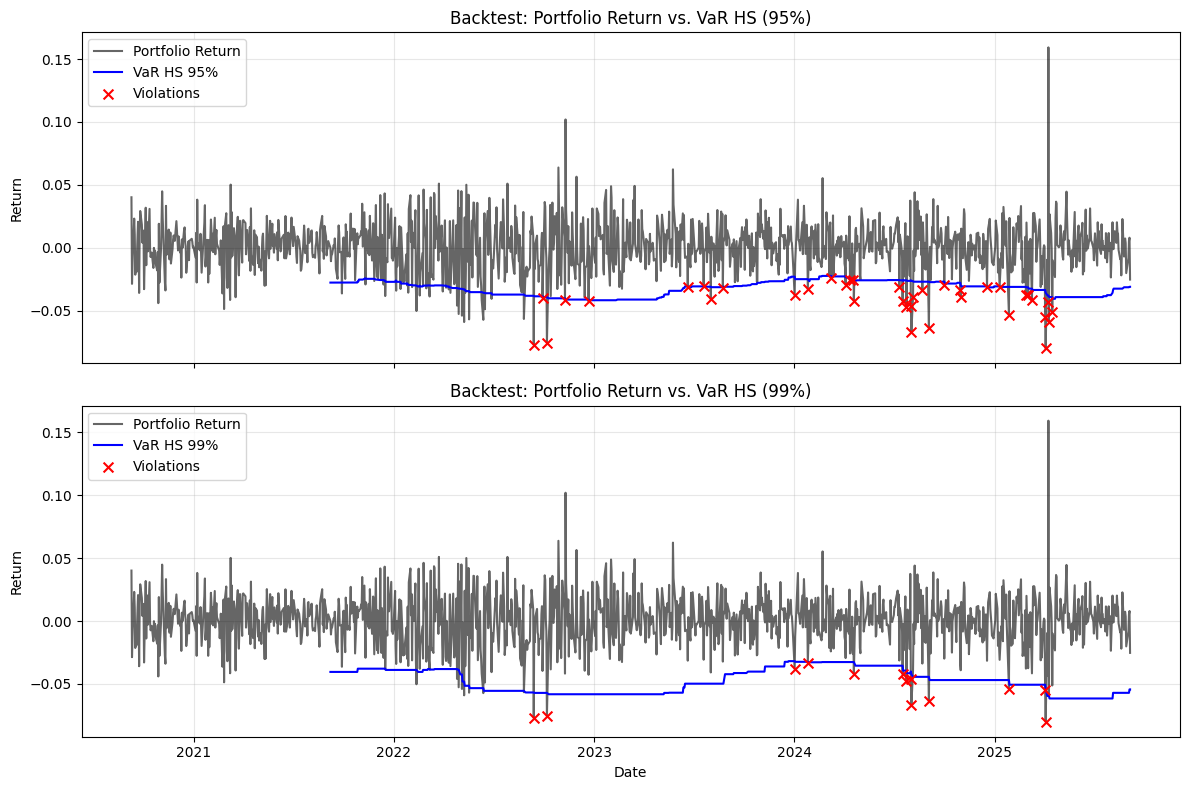

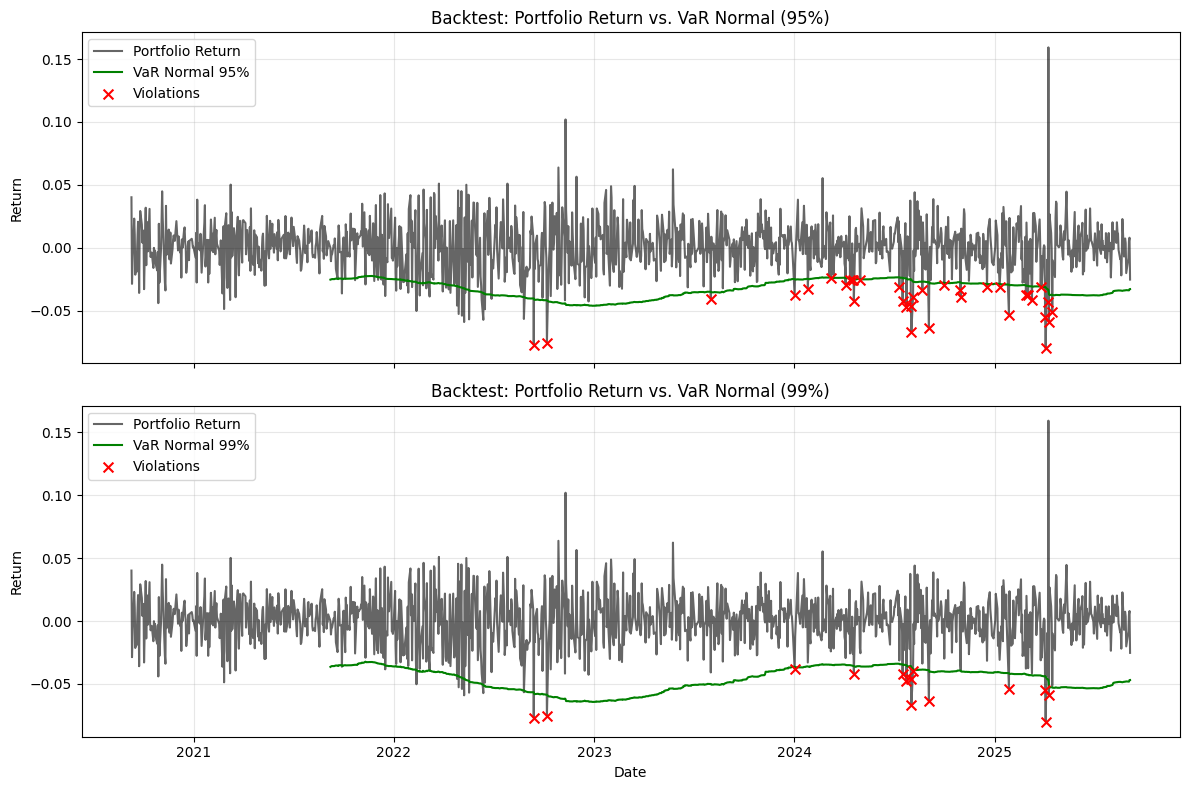

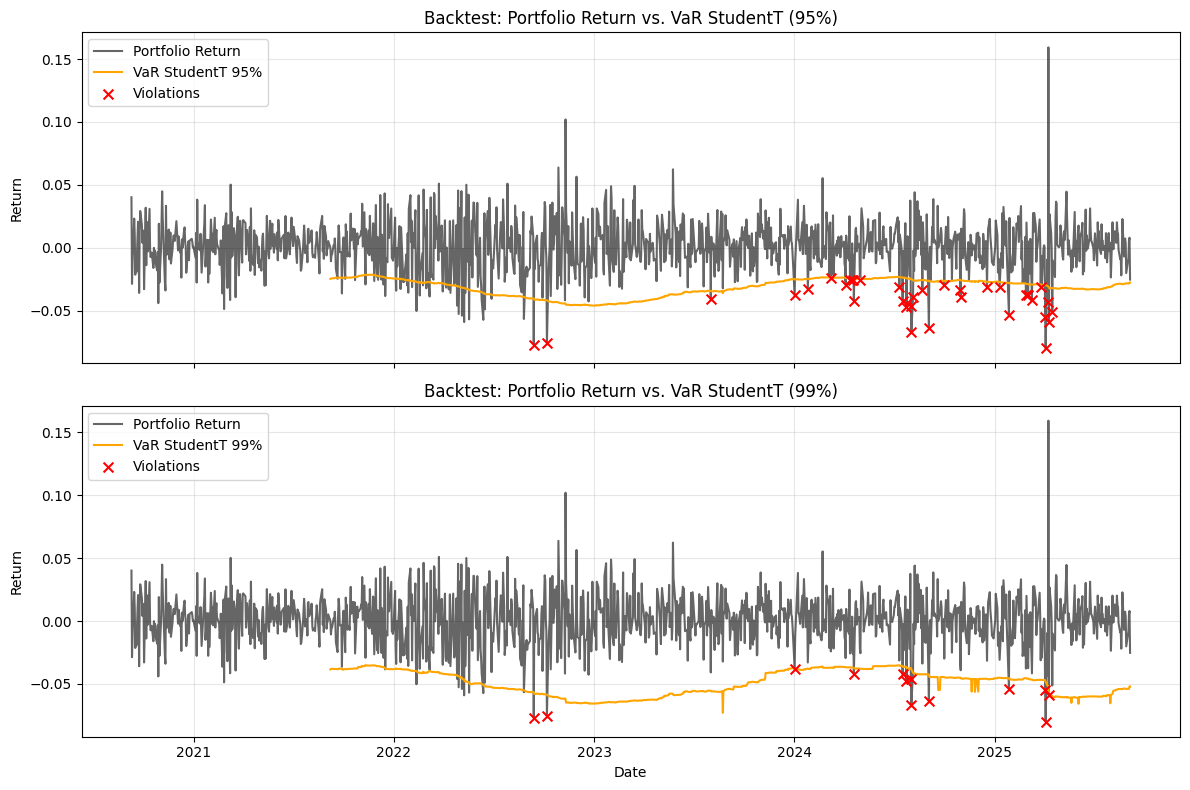

In [159]:
# Visualization (time series with violation boundary)
methods = ['HS', 'Normal', 'StudentT']
method_keys = ['violations_HS', 'violations_N', 'violations_T']
colors = ['blue', 'green', 'orange']

for i, (method, viol_key, color) in enumerate(zip(methods, method_keys, colors)):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # === 95% VaR ===
    ax1.plot(portfolio_returns.index, portfolio_returns, label="Portfolio Return", alpha=0.6, color='black')
    ax1.plot(df_VaR_roll.index, -df_VaR_roll[f'VaR_{method}_95%'], label=f"VaR {method} 95%", color=color)
    
    # Violations for this method at 95%
    violations95 = np.array(backtest_results[0.95][viol_key])
    violation_dates95 = df_VaR_roll.index[len(calibration_set):][violations95==1]
    ax1.scatter(violation_dates95, portfolio_returns.loc[violation_dates95],
                color="red", marker="x", s=50, label="Violations", zorder=5)
    
    ax1.set_title(f"Backtest: Portfolio Return vs. VaR {method} (95%)")
    ax1.set_ylabel("Return")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # === 99% VaR ===
    ax2.plot(portfolio_returns.index, portfolio_returns, label="Portfolio Return", alpha=0.6, color='black')
    ax2.plot(df_VaR_roll.index, -df_VaR_roll[f'VaR_{method}_99%'], label=f"VaR {method} 99%", color=color)
    
    # Violations for this method at 99%
    violations99 = np.array(backtest_results[0.99][viol_key])
    violation_dates99 = df_VaR_roll.index[len(calibration_set):][violations99==1]
    ax2.scatter(violation_dates99, portfolio_returns.loc[violation_dates99],
                color="red", marker="x", s=50, label="Violations", zorder=5)
    
    ax2.set_title(f"Backtest: Portfolio Return vs. VaR {method} (99%)")
    ax2.set_ylabel("Return")
    ax2.set_xlabel("Date")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Exercise IV
Part 1

In [ ]:
from scipy.stats import jarque_bera

# Conduct JB test
jb_results = {}
for stock in stocks_returns.columns:
    stat, p_value = jarque_bera(stocks_returns[stock].dropna())
    jb_results[stock] = {"JB_stat": stat, "p_value": p_value}

jb_df = pd.DataFrame(jb_results).T
print("Jarque-Bera test results:")
print(jb_df)


Jarque-Bera test results:
           JB_stat        p_value
AAPL   1211.923543  6.825688e-264
MSFT    396.411919   8.322340e-87
NVDA    670.299532  2.794512e-146
AMD     400.616103   1.016994e-87
INTC  10613.631779   0.000000e+00


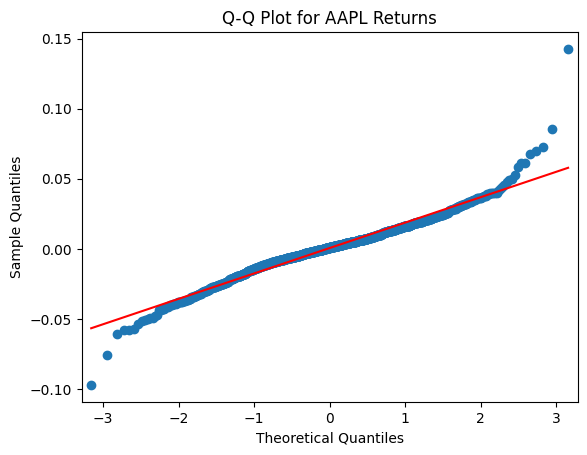

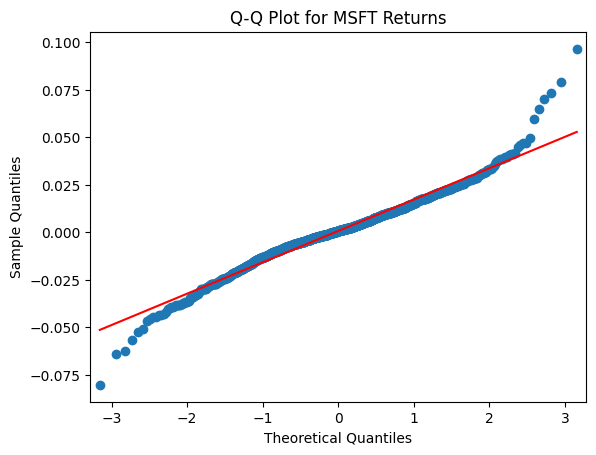

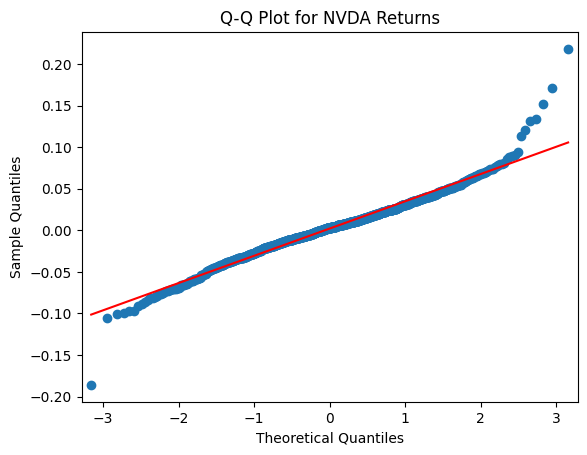

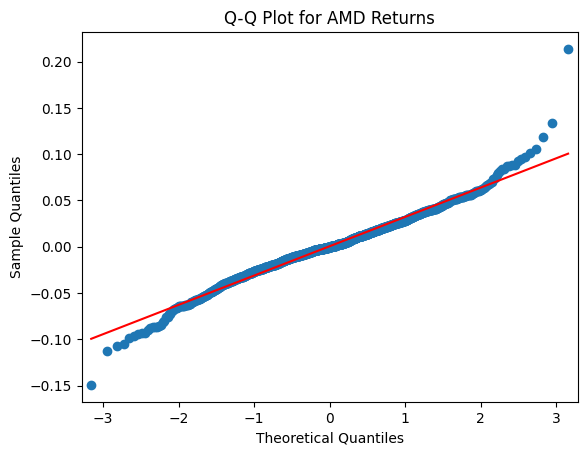

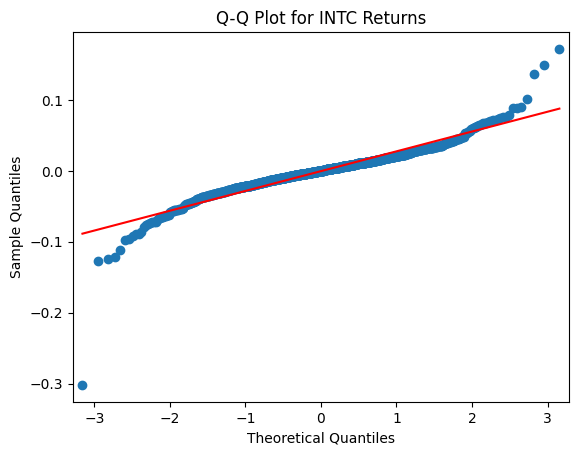

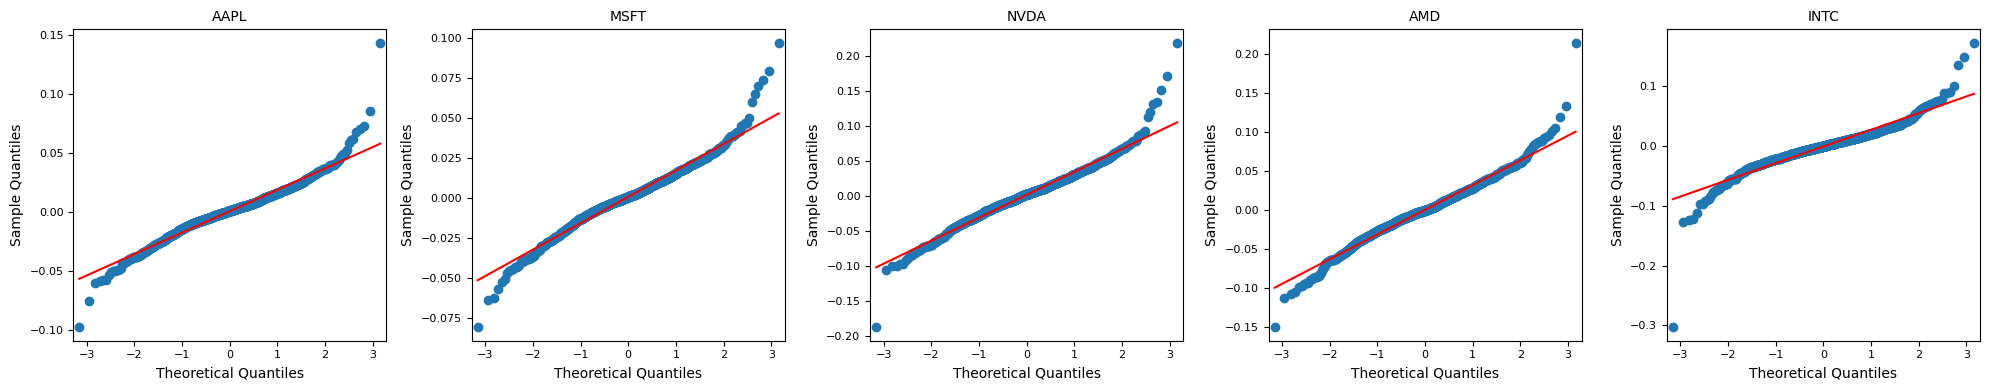

In [164]:
#QQ plots
for stock in stocks_returns.columns:
    sm.qqplot(stocks_returns[stock].dropna(), line='s')
    plt.title(f"Q-Q Plot for {stock} Returns")
    plt.show()
    
# QQ plot (all in one)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, stock in enumerate(stocks_returns.columns):
    sm.qqplot(stocks_returns[stock].dropna(), line='s', ax=axes[i])
    axes[i].set_title(f"{stock}", fontsize=10)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()


In [166]:
# Fitting Student-t dist to estimate degree of freedom
t_results = {}
for stock in stocks_returns.columns:
    data = stocks_returns[stock].dropna()
    df, loc, scale = t.fit(data) 
    t_results[stock] = {"df": df, "loc": loc, "scale": scale}

t_df = pd.DataFrame(t_results).T
print("Student-t fit results:")
print(t_df)

Student-t fit results:
            df       loc     scale
AAPL  4.142752  0.000886  0.013284
MSFT  4.602389  0.000928  0.012603
NVDA  5.257110  0.002202  0.025788
AMD   5.450864  0.000624  0.025315
INTC  3.406576  0.000049  0.018110


Part 2

In [ ]:
# Mardia's Test
"""
H0: The data follows a multivariate normal distribution
H1: The data does not follow a multivariate normal distribution.
"""
def mardiatest(X):
    n, p = X.shape
    mean = X.mean(axis=0)
    S = np.cov(X, rowvar=False)
    S_inv = np.linalg.inv(S)

    # Centered data
    Y = X - mean

    # Mardia's skewness
    b1p = (1/n**2) * np.sum([(Y[i].T @ S_inv @ Y[j])**3 for i in range(n) for j in range(n)])

    skew_stat = (n/6) * b1p
    df_skew = (p*(p+1)*(p+2))//6
    p_skew = 1 - chi2.cdf(skew_stat, df_skew)

    # Mardia's kurtosis
    b2p = (1/n) * np.sum((np.array([y.T @ S_inv @ y for y in Y]))**2)

    expected_kurt = p*(p+2)
    var_kurt = (8*p*(p+2))/n
    z_kurt = (b2p - expected_kurt) / np.sqrt(var_kurt)
    p_kurt = 2 * (1 - norm.cdf(abs(z_kurt)))

    # Decision rule
    sign_lvl = 0.05
    decision_skew = "reject the H0" if p_skew <= sign_lvl else "fail to reject the H0"
    decision_kurt = "reject the H0" if p_kurt <= sign_lvl else "fail to reject the H0"

    return {
        "Mardia_skewness": b1p,
        "Skewness_stat": skew_stat,
        "Skewness_pval": p_skew,
        "Decision for skewness": decision_skew,
        "Mardia_kurtosis": b2p,
        "Kurtosis_stat": z_kurt,
        "Kurtosis_pval": p_kurt,
        "Decision for kurtosis": decision_kurt
    }

# Execution
X = stocks_returns.dropna().values
mardiaresult = mardiatest(X)
# Store and print result
print(pd.DataFrame([mardiaresult]))

   Mardia_skewness  Skewness_stat  Skewness_pval Decision for skewness  \
0         3.170039     662.538084            0.0         reject the H0   

   Mardia_kurtosis  Kurtosis_stat  Kurtosis_pval Decision for kurtosis  
0        83.552013     102.748855            0.0         reject the H0  


In [171]:
# Sample skewness and excess kurtosis of each stock
for stock in stocks_returns.columns:
    stockdata = stocks_returns[stock].dropna()
    print(stock, "Skewness:", skew(stockdata), "Excess Kurtosis:", kurtosis(stockdata,fisher=True))


AAPL Skewness: 0.22826678659130273 Excess Kurtosis: 4.794401532005501
MSFT Skewness: 0.06850122304099 Excess Kurtosis: 2.751010963365073
NVDA Skewness: 0.21830524947058813 Excess Kurtosis: 3.5550063920216095
AMD Skewness: 0.11642903466683129 Excess Kurtosis: 2.75917939938261
INTC Skewness: -0.8842851225244664 Excess Kurtosis: 14.14227237668415


Part 3

In [172]:

mu_p = portfolio_losses.mean()
sigma_p = portfolio_losses.std(ddof=1)

# Fit Student-t to portfolio
df, loc, scale = t.fit(portfolio_losses)

var_results = []
for alpha in alphas:
    # Multivariate Normal VaR
    var_normal = (mu_p + sigma_p * norm.ppf(alpha)) 
    
    # Multivariate Student-t VaR
    var_t = (loc + scale * t.ppf(alpha, df))
    
    # Empirical distribution
    var_ed = np.quantile(portfolio_losses, alpha)
    
    var_results.append({
        "Alpha": alpha,
        "VaR_Normal": var_normal,
        "VaR_t": var_t,
        "VaR_ED": var_ed
    })

var_df = pd.DataFrame(var_results)
print(var_df)


   Alpha  VaR_Normal     VaR_t    VaR_ED
0   0.95    0.032480  0.030941  0.032344
1   0.99    0.046229  0.050498  0.053154


Part 4

In [179]:
# Diversification benefit
db_methods = ["Normal", "t", "ED"]

# Results storage
db_results = []

for alpha in alphas:
    # === Portfolio-level VaRs ===
    mu_p = portfolio_losses.mean()
    sigma_p = portfolio_losses.std(ddof=1)
    
    # Normal
    var_normal_p = (mu_p + sigma_p * norm.ppf(alpha))
    
    # Student-t
    df, loc, scale = t.fit(portfolio_losses)
    var_t_p = (loc + scale * t.ppf(alpha, df))
    
    # Empirical
    var_ed_p = np.quantile(portfolio_losses, alpha)
    
    portfolio_var = {
        "Normal": var_normal_p,
        "t": var_t_p,
        "ED": var_ed_p
    }
    
    # === Individual asset VaR ===
    indiv_var = {m: [] for m in db_methods}
    
    for stock in stocks_returns.columns:
        data = stocks_returns[stock].dropna()
        losses = -data
        # Normal
        mu_i, sigma_i = losses.mean(), losses.std(ddof=1)
        indiv_var["Normal"].append((mu_i + sigma_i * norm.ppf(alpha)))
        
        # Student-t
        df_i, loc_i, scale_i = t.fit(losses)
        indiv_var["t"].append(loc_i + scale_i * t.ppf(alpha, df_i))
        
        # Empirical
        indiv_var["ED"].append(np.quantile(losses, alpha))
    
    # Weighted sum of individual VaRs
    sum_indiv_var = {m: np.dot(weights, indiv_var[m]) for m in db_methods}
    
    # === Diversification benefit ===
    for method in db_methods:
        db =  sum_indiv_var[method] -portfolio_var[method]
        db_percent = (db/sum_indiv_var[method]) *100
        db_results.append({
            "Alpha": alpha,
            "Method": method,
            "Portfolio_VaR": portfolio_var[method],
            "Sum_Indiv_VaR": sum_indiv_var[method],
            "Diversification_Benefit": db,
            "Diversification_Benefit_%": db_percent
        })

# Convert to DataFrame
db_df = pd.DataFrame(db_results)
print("\nDiversification Benefit Results:")
print(db_df)


Diversification Benefit Results:
   Alpha  Method  Portfolio_VaR  Sum_Indiv_VaR  Diversification_Benefit  \
0   0.95  Normal       0.032480       0.041089                 0.008609   
1   0.95       t       0.030941       0.038273                 0.007332   
2   0.95      ED       0.032344       0.040083                 0.007739   
3   0.99  Normal       0.046229       0.058405                 0.012176   
4   0.99       t       0.050498       0.066071                 0.015573   
5   0.99      ED       0.053154       0.066164                 0.013010   

   Diversification_Benefit_%  
0                  20.952297  
1                  19.158217  
2                  19.307385  
3                  20.847308  
4                  23.570209  
5                  19.662954  
